## Betatron Oscillations Stability Study

Notebook to investigate the stability of the betatron oscillations as the module of K is increased, for a FODO arrangement with a fixed distance $d$ between the quadrupoles

### Core idea:

Given that $\beta(s)$ = $\zeta²(s)$, we know that $\zeta(s)$ is the single-valued continuous function which satisfies

\begin{equation}
    \zeta'' + K(s)\zeta - \frac{1}{\zeta³} = 0
\end{equation}

In regions where $K(s)$ is a constant, the equation above is equivalent to the motion of a particle (of coordinate $\zeta$) whose potential energy is

\begin{equation}
    V(\zeta) = K\zeta^2 + \frac{1}{\zeta^2}
\end{equation}

This, together with 

\begin{equation}
    \zeta'' = +\frac{\delta V}{\delta \zeta}
\end{equation}
gives an intuitive way of understanding the behavior of $\zeta$, being specified the values of $K$.

#### Potential Energy Shape

Since $K$ can be negative (defocusing), zero (drift) or positive (focusing), there are 3 main possibilities for the potential:

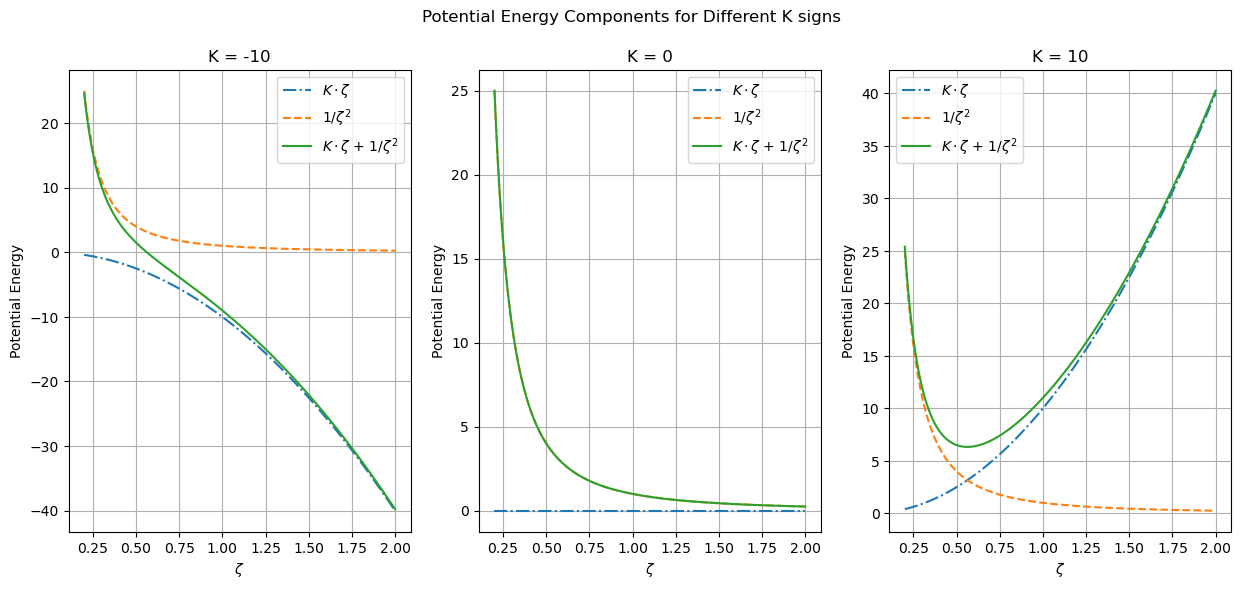

In [20]:
import numpy as np
import matplotlib.pyplot as plt

K = 10 # Module of quadrupoles' strength

Kd = -K # Defocusing quadrupole strength
Ko = 0 # Drift space (zero strength)
Kf = K # Focusing quadrupole strength

K_values = [Kd, Ko, Kf]

zeta = np.linspace(0.2, 2, 200)

def V(K, zeta):
    """Returns the potential energy components
    (1) Quadrupole potential, (2) "Centrifugal barrier", (3) Total potential."""
    return K*zeta**2, 1/zeta**2, K*zeta**2 + 1/zeta**2 

plt.figure(figsize=(15, 6))
for K in K_values:
    V_quad, V_cent, V_total = V(K, zeta)
    plt.subplot(1, 3, K_values.index(K) + 1)
    plt.plot(zeta, V_quad, label=r'$K\cdot \zeta$', linestyle='-.')
    plt.plot(zeta, V_cent, label=r'$1/\zeta^2$', linestyle='--')
    plt.plot(zeta, V_total, label=r'$K\cdot \zeta$ + $1/\zeta^2$')
    plt.title(f'K = {K}')
    plt.xlabel(r'$\zeta$')
    plt.ylabel('Potential Energy')
    plt.grid(True)
    plt.legend()

plt.suptitle('Potential Energy Components for Different K signs')
plt.show()


### Building the FODO line